# Figure 3: 3D Structure

Part A: FANC plots

In [ ]:
# Cell: imports
# use with environment workflow/env/fanc_jupyter.yml

import fanc
import fanc.plotting as fancplot
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import genomic_regions as gr

# Path to font (Liberation Sans: free, metric-compatible with Helvetica)
font_path = "../../doc/figures/helvetica/LiberationSans-Regular.ttf"

# Register the font
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Liberation Sans'

# Optional: Set as default for all text
plt.rcParams['font.sans-serif'] = ['Liberation Sans']
plt.rcParams['font.family'] = 'Liberation Sans'
plt.rcParams['font.size'] = 5
plt.rcParams['axes.titlesize'] = 7
plt.rcParams['axes.labelsize'] = 7
plt.rcParams['xtick.labelsize'] = 5
plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['legend.fontsize'] = 5

In [2]:
# Load reference tracks

genes = fanc.load("../../data/ref/chm13v2.0_RefSeq_Liftoff_v5.1.sorted.gtf.gz")
genes_no_exon = fanc.load("../../data/ref/epigenetics/chm13v2.0_RefSeq_Liftoff_v5.1.sorted.noexon.gtf.gz")
H3K27ac=fanc.load("../../data/ref/epigenetics/chm13v2.0_HL-60.H3K27ac.bw")
CTCF=fanc.load("../../data/ref/epigenetics/chm13v2.0_RWPE2.CTCF.bw")
motif=fanc.load("../../data/ref/epigenetics/CTCF_sites.gff")
cres = fanc.load("../../data/ref/epigenetics/encodeCcreCombined_chm13v2.bed")

In [3]:
# Load sample tracks
asm = "T2T12"

hic1 = fanc.load(f"../../analysis_other/porec/{asm}.hp1/hic/{asm}.hp1.hic@10000")
hic2 = fanc.load(f"../../analysis_other/porec/{asm}.hp2/hic/{asm}.hp2.hic@10000")

insu1= fanc.load(f"../../analysis_other/porec/{asm}.hp1/insulation/{asm}.hp1_25000.insulation.tsv.125000.bw")
insu2= fanc.load(f"../../analysis_other/porec/{asm}.hp2/insulation/{asm}.hp2_25000.insulation.tsv.125000.bw")

methyl1 = fanc.load(f"../../analysis_other/mod/{asm}/{asm}.ref.hp1.bw")
methyl2 = fanc.load(f"../../analysis_other/mod/{asm}/{asm}.ref.hp2.bw")

bound1 = fanc.load(f"../../analysis_other/porec/{asm}.hp1/tad/{asm}.hp1_40000_boundaries.gff")
bound2 = fanc.load(f"../../analysis_other/porec/{asm}.hp2/tad/{asm}.hp2_40000_boundaries.gff")

In [4]:
# Methylation smoothing with sliding window over CpG sites

import pyBigWig
from scipy.interpolate import interp1d

WINDOW_SIZE = 200

def smooth_methylation_cpg_window(bw_path, chrom, start, end, window_size=100):
    """
    Extract CpG methylation values and smooth using a sliding window of CpG sites.
    Returns interpolated values for genomic coordinates.
    """
    bw = pyBigWig.open(bw_path)
    
    # Get all intervals (CpG positions) in the region
    intervals = bw.intervals(chrom, start, end)
    bw.close()
    
    if intervals is None or len(intervals) == 0:
        return None, None
    
    # Extract positions and values
    positions = np.array([(iv[0] + iv[1]) / 2 for iv in intervals])  # midpoint of each CpG
    values = np.array([iv[2] for iv in intervals])
    
    # Apply sliding window smoothing over CpG sites
    smoothed_values = np.zeros(len(values))
    half_window = window_size // 2
    
    for i in range(len(values)):
        start_idx = max(0, i - half_window)
        end_idx = min(len(values), i + half_window + 1)
        smoothed_values[i] = np.mean(values[start_idx:end_idx])
    
    # Create interpolation function for genomic coordinates
    interp_func = interp1d(positions, smoothed_values, kind='linear', 
                           bounds_error=False, fill_value=np.nan)
    
    return positions, smoothed_values, interp_func

# Define region
chrom = "chr11"
region_start = 1500000
region_end = 2500000

# Paths to bigwig files
methyl1_path = f"../../analysis_other/mod/{asm}/{asm}.ref.hp1.bw"
methyl2_path = f"../../analysis_other/mod/{asm}/{asm}.ref.hp2.bw"

# Smooth methylation for both haplotypes
pos1, smooth1, interp1 = smooth_methylation_cpg_window(methyl1_path, chrom, region_start, region_end, window_size=WINDOW_SIZE)
pos2, smooth2, interp2 = smooth_methylation_cpg_window(methyl2_path, chrom, region_start, region_end, window_size=WINDOW_SIZE)

# Create dense genomic coordinates for plotting
genomic_coords = np.linspace(region_start, region_end, 2000)

# Interpolate smoothed values to dense coordinates
interp_smooth1 = interp1(genomic_coords)
interp_smooth2 = interp2(genomic_coords)

print(f"HP1: {len(pos1)} CpG sites")
print(f"HP2: {len(pos2)} CpG sites")

methyl_smoothed_data = {
    'coords': genomic_coords,
    'hp1': interp_smooth1,
    'hp2': interp_smooth2
}


HP1: 18874 CpG sites
HP2: 20111 CpG sites


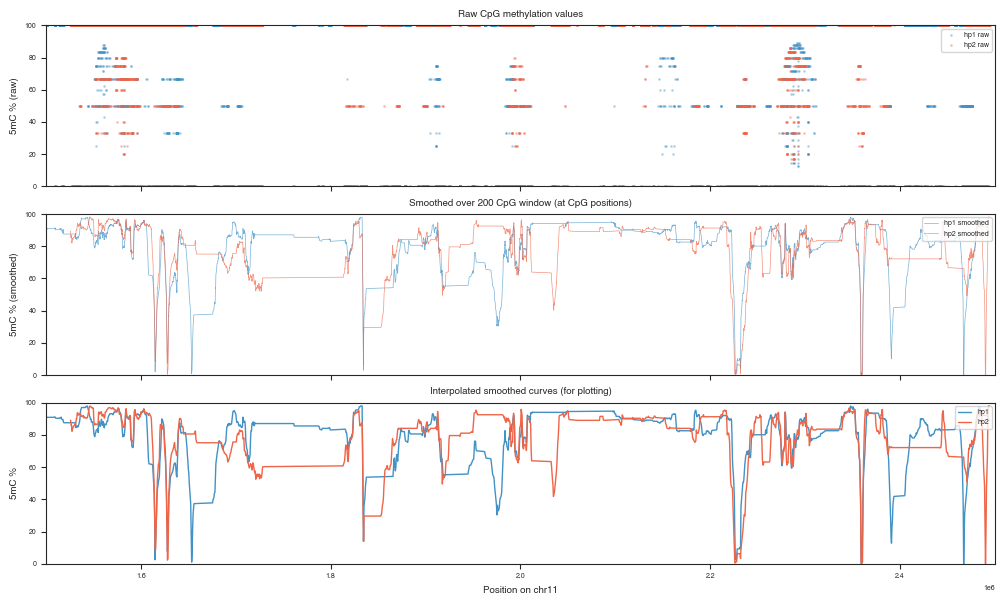

In [5]:
# Cell: Debug plot - methylation tracks only

import pyBigWig

# Re-extract raw values for scatter plot
bw1 = pyBigWig.open(methyl1_path)
bw2 = pyBigWig.open(methyl2_path)
raw1 = bw1.intervals(chrom, region_start, region_end)
raw2 = bw2.intervals(chrom, region_start, region_end)
bw1.close()
bw2.close()

# Extract positions and values separately
raw1_pos = np.array([(iv[0]+iv[1])/2 for iv in raw1])
raw1_val = np.array([iv[2] for iv in raw1])
raw2_pos = np.array([(iv[0]+iv[1])/2 for iv in raw2])
raw2_val = np.array([iv[2] for iv in raw2])

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

# Plot 1: Raw CpG methylation values
ax1 = axes[0]
ax1.scatter(raw1_pos, raw1_val, s=1, alpha=0.3, color="#4292c6", label='hp1 raw')
ax1.scatter(raw2_pos, raw2_val, s=1, alpha=0.3, color="#ef6548", label='hp2 raw')
ax1.set_ylabel("5mC % (raw)")
ax1.set_ylim(0, 100)
ax1.legend(loc='upper right', fontsize=5)
ax1.set_title("Raw CpG methylation values")

# Plot 2: Smoothed at CpG positions
ax2 = axes[1]
ax2.plot(pos1, smooth1, color="#4292c6", linewidth=0.5, alpha=0.7, label='hp1 smoothed')
ax2.plot(pos2, smooth2, color= "#ef6548", linewidth=0.5, alpha=0.7, label='hp2 smoothed')
ax2.set_ylabel("5mC % (smoothed)")
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right', fontsize=5)
ax2.set_title(f"Smoothed over {WINDOW_SIZE} CpG window (at CpG positions)")

# Plot 3: Interpolated smooth curves
ax3 = axes[2]
ax3.plot(genomic_coords, interp_smooth1, color="#4292c6", linewidth=1, label='hp1')
ax3.plot(genomic_coords, interp_smooth2, color="#ef6548", linewidth=1, label='hp2')
ax3.set_ylabel("5mC %")
ax3.set_ylim(0, 100)
ax3.set_xlabel(f"Position on {chrom}")
ax3.legend(loc='upper right', fontsize=5)
ax3.set_title("Interpolated smoothed curves (for plotting)")

# Format x-axis,
for ax in axes:
    ax.set_xlim(region_start, region_end)
    ax.grid(False)

plt.tight_layout()
plt.savefig("../../doc/figures/debug_methylation_smoothing.png", dpi=150)
plt.show()

In [6]:
# Create GenomicRegion lists from methyl_smoothed_data
regions_hp1 = [
    gr.GenomicRegion("11", int(pos), int(pos) + 1, score=float(val))
    for pos, val in zip(methyl_smoothed_data['coords'], methyl_smoothed_data['hp1'])
]
regions_hp2 = [
    gr.GenomicRegion("11", int(pos), int(pos) + 1, score=float(val))
    for pos, val in zip(methyl_smoothed_data['coords'], methyl_smoothed_data['hp2'])
]

meth_gr_hp1 = gr.RegionWrapper(regions_hp1)
meth_gr_hp2 = gr.RegionWrapper(regions_hp2)

In [7]:
# Load sample tracks
asm = "T2T12"

hic1 = fanc.load(f"../../analysis_other/porec/{asm}.hp1/hic/{asm}.hp1.hic@10000")
hic2 = fanc.load(f"../../analysis_other/porec/{asm}.hp2/hic/{asm}.hp2.hic@10000")

insu1= fanc.load(f"../../analysis_other/porec/{asm}.hp1/insulation/{asm}.hp1_25000.insulation.tsv.125000.bw")
insu2= fanc.load(f"../../analysis_other/porec/{asm}.hp2/insulation/{asm}.hp2_25000.insulation.tsv.125000.bw")

methyl1 = fanc.load(f"../../analysis_other/mod/{asm}/{asm}.ref.hp1.bw")
methyl2 = fanc.load(f"../../analysis_other/mod/{asm}/{asm}.ref.hp2.bw")

bound1 = fanc.load(f"../../analysis_other/porec/{asm}.hp1/tad/{asm}.hp1_25000_boundaries.gff")
bound2 = fanc.load(f"../../analysis_other/porec/{asm}.hp2/tad/{asm}.hp2_25000_boundaries.gff")

/mnt/storage2/users/ahgrosc1/environments/envs/fanc/lib/python3.8/site-packages/fanc/compatibility/juicer.py:793: UserWarning: Cannot find normalisation vector for chromosome: Y, normalisation: KR, resolution: 10000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will return NaN instead.
  warnings.warn("Cannot find normalisation vector for "
/mnt/storage2/users/ahgrosc1/environments/envs/fanc/lib/python3.8/site-packages/fanc/compatibility/juicer.py:793: UserWarning: Cannot find normalisation vector for chromosome: M, normalisation: KR, resolution: 10000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will return NaN instead.
  warnings.warn("Cannot find normalisation vector for "


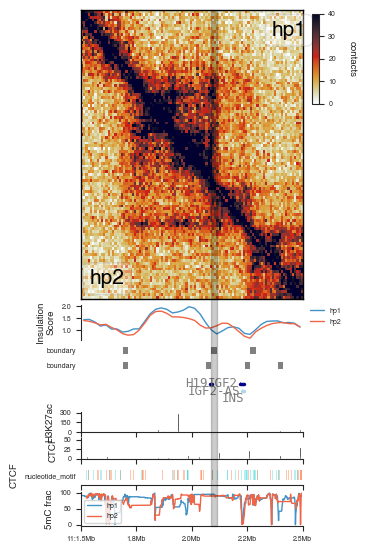

In [8]:
# H19 Plot

matrix = fancplot.SplitMatrixPlot(hic1, hic2, draw_ticks=False, draw_x_axis=False, vmax=40,
                                   aspect=1, scale_matrices=False)

insu = fancplot.LinePlot((insu1, insu2),
                         fill=False, fix_chromosome=True, labels=('hp1', 'hp2'),
                         colors=("#4292c6", "#ef6548"), ylabel="Insulation\nScore", style="mid",
                         aspect=0.12,
                         plot_kwargs={"linewidth": 1}, draw_x_axis=False)

borders1 = fancplot.FeatureLayerPlot(bound1,
                                      fix_chromosome=True, aspect=0.03,
                                      ylabel="", draw_x_axis=False,
                                      )

borders2 = fancplot.FeatureLayerPlot(bound2,
                                      fix_chromosome=True, aspect=0.03,
                                      ylabel="", draw_x_axis=False,
                                      )


gene_plot = fancplot.GenePlot(genes, group_by="gene_id", label_field="gene_id",
                               fix_chromosome=True, squash=True, aspect=0.1,
                               color_forward="lightblue", color_reverse="darkblue", ylabel="genes",
                               include={"gene_id": ["H19", "IGF2", "IGF2-AS", "INS"]},
                               line_width=2.5, box_height=0.5, show_arrows=False, draw_x_axis=False)

highlight = fancplot.HighlightAnnotation([("chr11", 2087500, 2112500)],
                                          fix_chromosome=True,
                                          plot_kwargs={"alpha": 0.2,
                                                       "color": "black",
                                                       "linewidth": 1})

histone = fancplot.BarPlot(H3K27ac, fix_chromosome=True,
                            bin_size=5000, alpha=1,
                            ylabel="H3K27ac",
                            aspect=0.07,
                            plot_kwargs={"color": "black"})

ctcf = fancplot.BarPlot(CTCF, fix_chromosome=True,
                         bin_size=5000, alpha=1,
                         ylabel="CTCF",
                         aspect=0.07,
                         plot_kwargs={"color": "black"})

sites = fancplot.FeatureLayerPlot(motif,
                                   fix_chromosome=True,
                                   ylabel="CTCF",
                                   aspect=0.07,
                                   color_by="strand", element_height=0.5)

enh = fancplot.FeatureLayerPlot(cres, fix_chromosome=True,
                                 ylabel="CREs",
                                 aspect=0.07, collapse=True)

meth = fancplot.LinePlot(
    (meth_gr_hp1, meth_gr_hp2),
    fill = False,
    colors=("#4292c6", "#ef6548"),
    labels=('hp1', 'hp2'),
    ylabel="5mC frac",
    aspect=0.12,
    plot_kwargs={"linewidth": 1}
)

gf = fancplot.GenomicFigure([matrix, insu, 
                              borders1, borders2,
                              gene_plot,
                              histone,
                              ctcf,
                              sites,
                              meth,
                              highlight
                              ], ticks_last=True, 
                              width=4.5)

fig, axes = gf.plot('11:1.5mb-2.5mb')
fig.set_size_inches(3.5, 6)

cbar_ax = fig.axes[1]
cbar_ax.set_ylabel("contacts", rotation=270, labelpad=15, fontsize=7)
cbar_ax.set_position([0.8, 0.79, 0.02, 0.15])

matrix_ax = axes[0]

matrix_ax.text(0.86, 0.91, "hp1", transform=matrix_ax.transAxes, fontsize=15, color="black", 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.3, edgecolor='darkgrey'))
matrix_ax.text(0.04, 0.05, "hp2", transform=matrix_ax.transAxes, fontsize=15, color="black", 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.3, edgecolor='darkgrey'))

for spine in matrix_ax.spines.values(): 
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

line_ax = axes[1]
handles, labels = line_ax.get_legend_handles_labels()
line_ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False, fontsize=5)

gene_ax = axes[3]
for label in gene_ax.texts:
    label.set_color("black")
    label.set_fontsize(5)

# Methylation legend
methyl_ax = axes[7]
handles, labels = methyl_ax.get_legend_handles_labels()
methyl_ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False, fontsize=5)

for ax in axes:
    ax.grid(False)

fig.show()
fig.savefig("../../doc/figures/fig3_fanc_H19_big.png", dpi=500)
fig.savefig("../../doc/figures/fig3_fanc_H19_big.pdf", dpi=500)

## B: X Chromosome Plot

In [ ]:
WINDOW_SIZE = 100000

# Load Pore-C data at appropriate resolution
hic1 = fanc.load("../../analysis_other/porec/T2T12.hp1/hic/T2T12.hp1.hic@100000")
hic2 = fanc.load("../../analysis_other/porec/T2T12.hp2/hic/T2T12.hp2.hic@100000")

insu1 = fanc.load("../../analysis_other/porec/T2T12.hp1/insulation/T2T12.hp1_40000.insulation.tsv.1000000.bw")
insu2 = fanc.load("../../analysis_other/porec/T2T12.hp2/insulation/T2T12.hp2_40000.insulation.tsv.1000000.bw")

# Prepare methylation data for chrX
chrom = "chrX"
region_start = 0
region_end = 154259566  # Length of chrX in T2T-CHM13v2.0

methyl1_path = f"../../analysis_other/mod/{asm}/{asm}.ref.hp1.bw"
methyl2_path = f"../../analysis_other/mod/{asm}/{asm}.ref.hp2.bw"

# Smooth methylation for both haplotypes
pos1_x, smooth1_x, interp1_x = smooth_methylation_cpg_window(methyl1_path, chrom, region_start, region_end, window_size=WINDOW_SIZE)
pos2_x, smooth2_x, interp2_x = smooth_methylation_cpg_window(methyl2_path, chrom, region_start, region_end, window_size=WINDOW_SIZE)

# Create dense genomic coordinates
genomic_coords_x = np.linspace(region_start, region_end, 2000)
interp_smooth1_x = interp1_x(genomic_coords_x)
interp_smooth2_x = interp2_x(genomic_coords_x)

# Create GenomicRegion lists for methylation
regions_hp1_x = [
    gr.GenomicRegion("X", int(pos), int(pos) + 1, score=float(val))
    for pos, val in zip(genomic_coords_x, interp_smooth1_x)
    if not np.isnan(val)
]
regions_hp2_x = [
    gr.GenomicRegion("X", int(pos), int(pos) + 1, score=float(val))
    for pos, val in zip(genomic_coords_x, interp_smooth2_x)
    if not np.isnan(val)
]

meth_gr_hp1_x = gr.RegionWrapper(regions_hp1_x)
meth_gr_hp2_x = gr.RegionWrapper(regions_hp2_x)

/mnt/storage2/users/ahgrosc1/environments/envs/fanc/lib/python3.8/site-packages/fanc/compatibility/juicer.py:793: UserWarning: Cannot find normalisation vector for chromosome: Y, normalisation: KR, resolution: 100000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will return NaN instead.
  warnings.warn("Cannot find normalisation vector for "
/mnt/storage2/users/ahgrosc1/environments/envs/fanc/lib/python3.8/site-packages/fanc/compatibility/juicer.py:793: UserWarning: Cannot find normalisation vector for chromosome: M, normalisation: KR, resolution: 100000, unit: BP. This could indicate that KR normalisation did not work for this chromosome. Will return NaN instead.
  warnings.warn("Cannot find normalisation vector for "
/tmp/ipykernel_2241797/38260697.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


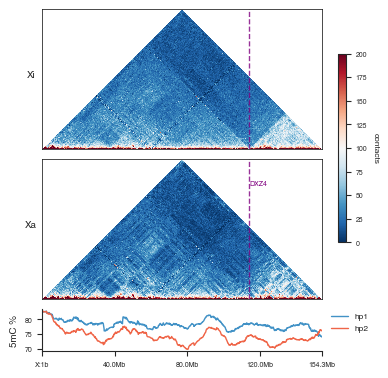

In [10]:
# Create triangular matrix plots - disable colorbar on second matrix
matrix1 = fancplot.TriangularMatrixPlot(hic1, vmin=0, vmax=200, 
                                        draw_ticks=False, draw_x_axis=False,
                                        colormap='RdBu_r', aspect=0.5)

matrix2 = fancplot.TriangularMatrixPlot(hic2, vmin=0, vmax=200,
                                        draw_ticks=False, draw_x_axis=False,
                                        colormap='RdBu_r', aspect=0.5,
                                        show_colorbar=False)  # Hide second colorbar

# Methylation plot
meth = fancplot.LinePlot(
    (meth_gr_hp1_x, meth_gr_hp2_x),
    fill=False,
    colors=("#4292c6", "#ef6548"),
    labels=('hp1', 'hp2'),
    ylabel="5mC %",
    aspect=0.15,
    plot_kwargs={"linewidth": 1}
)

# Create figure - 80mm width = ~3.15 inches
gf = fancplot.GenomicFigure([matrix1, matrix2, meth], 
                            ticks_last=True, width=2.8)

# Use 'X' without chr prefix to match Hi-C data
fig, axes = gf.plot('X:1-154259566')

# Format colorbar (single legend for both matrices) - move beside plot
cbar_ax = fig.axes[1]
cbar_ax.set_ylabel("contacts", rotation=270, labelpad=8, fontsize=6)
cbar_ax.yaxis.set_label_position('right')
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.set_position([0.733, 0.4, 0.015, 0.4])

# Add labels to matrices (no rotation)
matrix1_ax = axes[0]
matrix1_ax.set_ylabel("Xi", fontsize=7, rotation=0, labelpad=8)


matrix2_ax = axes[1]
matrix2_ax.set_ylabel("Xa", fontsize=7, rotation=0, labelpad=8)


# Format borders
for matrix_ax in [matrix1_ax, matrix2_ax]:
    for spine in matrix_ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.5)

# Add DXZ4 label on the second matrix plot (spans both visually)
dxz4_pos = 114000000
for ax in [matrix1_ax, matrix2_ax]:
    ax.axvline(x=dxz4_pos, color='purple', linewidth=1, linestyle='--', alpha=0.8)

matrix2_ax.text(dxz4_pos + 5e6, 0.8, 'DXZ4', transform=matrix2_ax.get_xaxis_transform(),
                fontsize=5, color='purple', weight='bold', ha='center', va='bottom')

# Methylation legend
meth_ax = axes[2]
handles, labels = meth_ax.get_legend_handles_labels()
meth_ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), 
              borderaxespad=0, frameon=False, fontsize=6)

# Remove grid from all axes
for ax in axes:
    ax.grid(False)

fig.tight_layout()
fig.savefig("../../doc/figures/fig3_fanc_chrX_full.png", dpi=300, bbox_inches='tight')
fig.show()
